In [3]:
import glob
import numpy as np
from numpy.testing import assert_array_equal, assert_allclose
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import darshan
from darshan.experimental.plots import heatmap_handling, plot_dxt_heatmap
from darshan.log_utils import get_log_path
darshan.enable_experimental(verbose=True)

Added method darshan.experimental.aggregators.mod_agg_iohist to DarshanReport.
Added method darshan.experimental.aggregators.create_time_summary to DarshanReport.
Added method darshan.experimental.aggregators.print_module_records to DarshanReport.
Added method darshan.experimental.aggregators.create_timeline to DarshanReport.
Added method darshan.experimental.aggregators.summarize to DarshanReport.
Added method darshan.experimental.aggregators.create_dxttimeline to DarshanReport.
Added method darshan.experimental.aggregators.agg_ioops to DarshanReport.
Added method darshan.experimental.aggregators.name_records_summary to DarshanReport.
Added method darshan.experimental.aggregators.records_as_dict to DarshanReport.
Added method darshan.experimental.aggregators.create_sankey to DarshanReport.
Added method darshan.experimental.operations.filter to DarshanReport.
Added method darshan.experimental.operations.reduce to DarshanReport.
Added method darshan.experimental.operations.merge to Dars

In [4]:
def filter_record(r,ex_list=[],in_list=[]):
    nr=r.name_records
    # import fname,re
    names=list(nr.values())
    for k, v in nr.items():
        inclu=True
        if in_list!=[]:
            inclu=False
            for i in in_list:
                if i in v:
                    inclu=True
                    break
        if ex_list!=[]:
            for ex in ex_list:
                if ex in v:
                    inclu=False
        if not inclu:
            names.remove(v)
#     print(names)
#     print(set([x.split('/')[-1] for x in names]))
#     print('before',r.agg_ioops()['POSIX_simple']['Read'],r.agg_ioops()['POSIX_simple']['Write'])
#     print('after',r.reduce(name_records=names).agg_ioops()['POSIX_simple']['Read'],r.agg_ioops()['POSIX_simple']['Write'])
#     r=r.reduce(name_records=names)
#     return r #.reduce(name_records=names)
    return names


In [5]:
ex_list=['.py','perfmon','.pmon.','PoolFileCatalog','eventLoopHeartBeat','.db','.so','atlas-condb','.conditions.','.txt'
         ,'.tmp','.log','Log','STD','POSIX']
in_list=['.pool.root']
files=glob.glob('workdir/Derivation/Athena_23_0_12/data/athenaMP*/rwang*.darshan')
reports=[darshan.DarshanReport(file, read_all=True, dtype='numpy') for file in files]
# freports=[filter_record(r,ex_list,in_list) for r in reports]
freports=[r.reduce(name_records=filter_record(r,ex_list,in_list)) for r in reports]
print(freports[4].agg_ioops()['POSIX_simple']['Read'],reports[4].agg_ioops()['POSIX_simple']['Write'])

351 80


In [6]:
df=pd.DataFrame(columns=['athena','proc','evt','fork','time'
                               ,'posix read','posix write','posix open','posix stat','posix seek','posix mmap','posix fsync'
                              ,'posix bytes read','posix bytes written','posix max bytes read','posix max bytes written'])

for r in freports:
#     r=filter_record(r,ex_list,in_list)
#     print(r.name_records)
#     print('shared_writer' in r.name_records)
    file=r.filename.split('/')[-2].split('_')
#     print(file)
    athena=file[0]
    if 'athenaMP' in athena and file[-2]=='true': athena+='_shared'
    if 'athenaMP' in athena and file[-1]=='true': athena+='_parComp'
#     print(file[-2],file[-1],athena)
    athena+=' ('+file[1]+')'
    time=r.end_time-r.start_time
    posix_read=r.agg_ioops()['POSIX_simple']['Read']
    posix_write=r.agg_ioops()['POSIX_simple']['Write']
    posix_open=r.agg_ioops()['POSIX_simple']['Open']
    posix_stat=r.agg_ioops()['POSIX_simple']['Stat']
    posix_seek=r.agg_ioops()['POSIX_simple']['Seek']
    posix_mmap=r.agg_ioops()['POSIX_simple']['Mmap']
    posix_fsync=r.agg_ioops()['POSIX_simple']['Fsync']
    posix_bytes_read=r.agg_ioops()['POSIX']['POSIX_BYTES_READ']/1024/1024.
    posix_bytes_written=r.agg_ioops()['POSIX']['POSIX_BYTES_WRITTEN']/1024./1024
    posix_max_bytes_read=r.agg_ioops()['POSIX']['POSIX_MAX_BYTE_READ']/1024./1024
    posix_max_bytes_written=r.agg_ioops()['POSIX']['POSIX_MAX_BYTE_WRITTEN']/1024/1024.
    isfork='worker' if 'fork_parent' in r.metadata['job']['metadata'].keys() else 'main'
    if 'MergePool_tf' in r.metadata['exe']:
        isfork='merge'
    if isfork=='worker' and 'shared' in athena:
        for k,v in r.name_records.items():
            if 'shared_writer' in v:
                isfork='shared_writer'
                break
    if isfork=='worker':
        for k,v in r.name_records.items():
            if 'evt_counter' in v:
                isfork='evt_counter'
                break
        
#     print(file[0],file[2],file[3],isfork)
    df.loc[len(df)]=[athena,int(file[2]),int(file[3]),isfork,time
                     ,posix_read,posix_write,posix_open,posix_stat,posix_seek,posix_mmap,posix_fsync
                    ,posix_bytes_read,posix_bytes_written,posix_max_bytes_read,posix_max_bytes_written]
# print(df[(df.fork=='worker') & (df.proc==16) & (df.evt==500) ].sort_values(['evt','athena','proc'])['athena'].to_list())
print(list(df.athena.unique()))
print(df[(df.fork=='main') & (df.athena=='athenaMP_shared_parComp (PHYS)')].sort_values(['evt','athena','proc']))


['athenaMP (PHYS)', 'athenaMP_shared (PHYS)', 'athenaMP_shared (PHYSLITE)', 'athenaMP_shared_parComp (PHYSLITE)', 'athenaMP (PHYSLITE)', 'athenaMP_shared_parComp (PHYS)']
                              athena  proc   evt  fork            time  \
901   athenaMP_shared_parComp (PHYS)     8  1200  main 0 days 00:13:36   
1227  athenaMP_shared_parComp (PHYS)    16  1200  main 0 days 00:14:38   
281   athenaMP_shared_parComp (PHYS)    32  1200  main 0 days 00:18:36   
216   athenaMP_shared_parComp (PHYS)     8  2400  main 0 days 00:23:44   
861   athenaMP_shared_parComp (PHYS)    16  2400  main 0 days 00:26:02   
1508  athenaMP_shared_parComp (PHYS)    32  2400  main 0 days 00:33:41   
727   athenaMP_shared_parComp (PHYS)     8  3600  main 0 days 00:34:30   
1763  athenaMP_shared_parComp (PHYS)    16  3600  main 0 days 00:41:09   
1565  athenaMP_shared_parComp (PHYS)    32  3600  main 0 days 00:49:35   

      posix read  posix write  posix open  posix stat  posix seek  posix mmap  \
901    

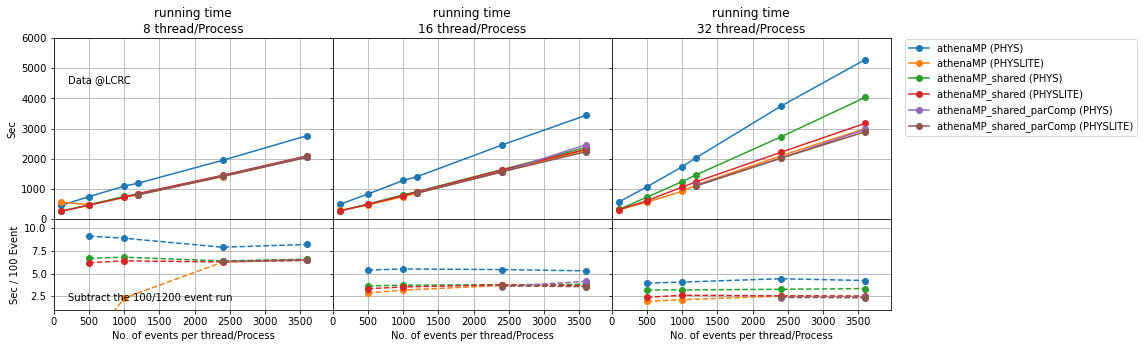

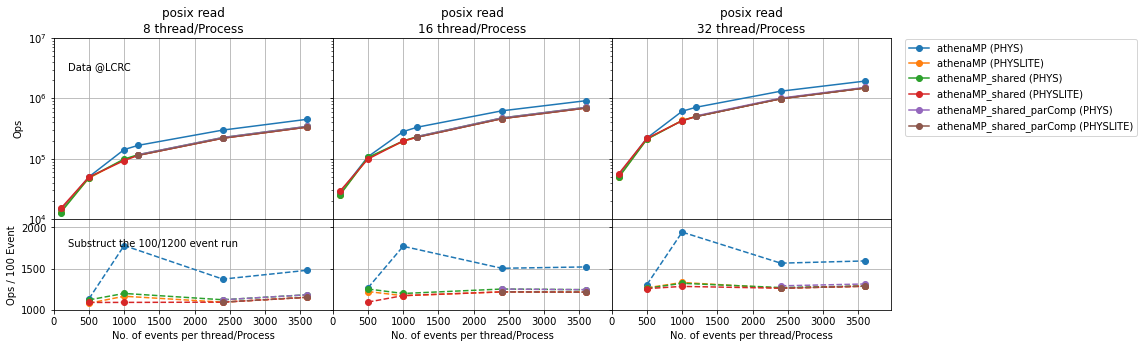

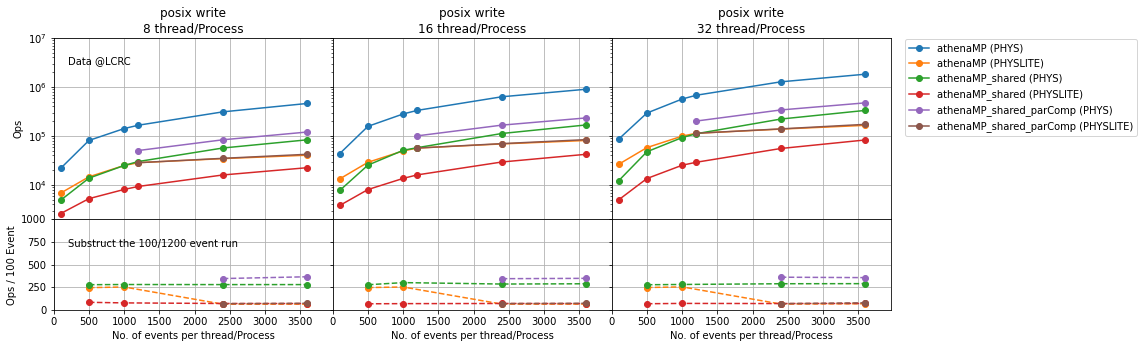

In [13]:
def plot_withfork(df,var,op,tit,ylabel,logy,ylim,ylim2):
    if 'time' in var:
        df_main=df.query("fork!='worker' and fork!='shared_writer' and fork!='evt_counter'",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
        df[var]=df[var].astype("timedelta64[s]")
    else:
        df_main=df.sort_values(['evt','athena','proc']).reset_index(drop=True)
    df_main=df_main.groupby(['evt','athena','proc']).agg({var:op})
#     print(df_main.head(2))
    if op=='max':
        df_max_idx = df.groupby(['evt','athena','proc'])[var].transform(max) == df[var]
#         print(df[df_max_idx])
    df_main=df_main.reset_index(level=[0,1,2])
#     print(df_main)
    df_main[var+'_sub']=df_main[var]
    subns=[100,1200]
    for nevt in list(df_main.evt.unique()):
        if nevt>=subns[1]: subn=subns[1]
        else: subn=subns[0]
        if nevt in subns: continue
#         print(nevt,type(nevt))
#         print("substruct",subn)
#         lenth=len(df_main.loc[df_main.evt==nevt,var+'_sub'])
#         print(df_main.loc[df_main.evt==nevt])
#         print(df_main.loc[df_main.evt==subn])
        df_main.loc[df_main.evt==nevt,var+'_sub']=(df_main.loc[df_main.evt==nevt,var+'_sub']-df_main.loc[df_main.evt==subn][var].values)
        df_main.loc[df_main.evt==nevt,var+'_sub']=df_main.loc[df_main.evt==nevt,var+'_sub']/(nevt-subn)/df_main.loc[df_main.evt==nevt,'proc']*100

    fig1,ax = plt.subplots(2,3,figsize=(15, 5),gridspec_kw={
                           'height_ratios':[2, 1],'wspace':0,'hspace':0}
                           ,sharex=True,sharey=False)
#     fig2,ax2 = plt.subplots(1,3,figsize=(15, 3),sharex=True,sharey=True)
    xlabel='No. of events per thread/Process'
    df_main.set_index(['evt'],inplace=True)
#     print(df_main)
    for i,p in enumerate(np.sort(df_main.proc.unique())):
        title=tit+'\n'+str(p)+' thread/Process'
        df_main.loc[df_main.proc==p].groupby(['athena'])[var].plot(xlabel=xlabel,ylabel=ylabel,marker='o',ax=ax[0][i]
                                                                   ,title=title,logy=logy,legend=False,grid=True
                                                                  ,xlim=[0,nevt*1.1],ylim=ylim)
        df_main.loc[(df_main.proc==p) & (df_main.index!=subns[0]) & (df_main.index!=subns[1])].groupby(['athena'])[var+'_sub'].plot(stacked=False,marker='o',linestyle='dashed'
                                                                    ,xlabel=xlabel,ylabel=ylabel+' / 100 Event',ax=ax[1][i]
                                                                    ,xlim=[0,nevt*1.1],ylim=ylim2,logy=False,grid=True)
    
    if logy:
        ax[0][0].text(200,ax[0][0].get_ylim()[1]*0.3,'Data @LCRC')
        ax[1][0].text(200,ax[1][0].get_ylim()[0]+(ax[1][0].get_ylim()[1]-ax[1][0].get_ylim()[0])*0.7,'Substruct the 100/1200 event run')
    else:
        ax[0][0].text(200,ax[0][0].get_ylim()[1]*0.75,'Data @LCRC')
        ax[1][0].text(200,ax[1][0].get_ylim()[0]*2,'Subtract the 100/1200 event run')
    ax[0][2].legend(bbox_to_anchor=(1.9,1.02), loc="upper right")
    for i in [0,1]:
        for j in [1,2]:
            ax[i][j].tick_params('y', labelleft=False)
            ax[i][j].set_ylabel('')
#     fig1.subplots_adjust(0,0,1,1,0,0)
#     fig2.subplots_adjust(0,0,1,1,0,0)

# plt.tight_layout()
# df_main
plot_withfork(df,'time','sum','running time','Sec',False,[0,6000],[1,11])
plot_withfork(df,'posix read','sum','posix read','Ops',True,[10**4,10**7],[1000,2100])
plot_withfork(df,'posix write','sum','posix write','Ops',True,[2000,10**7],[0,1000])
# plot_withfork(df,'posix bytes read','sum','posix read','MB',True,[0.2,5000],[0.005,12])
# plot_withfork(df,'posix bytes written','sum','posix write','MB',True,[0.2,5000],[0.2,10])
# for ops in [x for x in df.columns if 'posix' in x]:
#     op='max' if 'max' in ops else 'sum' 
#     plot_withfork(df,ops,op,ops,'Ops',False)
# plot_withfork(df,'posix_read','posix read','Ops (Total, All Processes)')
# plot_withfork(df,'posix_write','posix write','Ops (Total, All Processes)')


               athena  proc  evt         fork   time  posix read  posix write  \
1160  athenaMP (PHYS)     8  100       worker   65.0        1536         1649   
1161  athenaMP (PHYS)     8  100       worker   62.0        1489         1361   
1162  athenaMP (PHYS)     8  100  evt_counter    2.0         175           77   
1163  athenaMP (PHYS)     8  100       worker   56.0        1561         1576   
1164  athenaMP (PHYS)     8  100       worker   55.0        1960         1464   
1165  athenaMP (PHYS)     8  100       worker   59.0        1499         1462   
1166  athenaMP (PHYS)     8  100         main  249.0         480           77   
1167  athenaMP (PHYS)     8  100        merge  205.0         728        10003   
1168  athenaMP (PHYS)     8  100       worker   64.0        1464         1471   
1169  athenaMP (PHYS)     8  100       worker   61.0        1589         1382   
1170  athenaMP (PHYS)     8  100       worker   58.0        1558         1425   

      posix open  posix sta

                          athena  proc  evt           fork   time  posix read  \
1668  athenaMP_shared (PHYSLITE)     8  100         worker   66.0        1742   
1669  athenaMP_shared (PHYSLITE)     8  100         worker   57.0        1723   
1670  athenaMP_shared (PHYSLITE)     8  100         worker   64.0        1719   
1671  athenaMP_shared (PHYSLITE)     8  100         worker   55.0        2155   
1672  athenaMP_shared (PHYSLITE)     8  100         worker   59.0        1725   
1673  athenaMP_shared (PHYSLITE)     8  100         worker   63.0        1732   
1674  athenaMP_shared (PHYSLITE)     8  100         worker   62.0        1688   
1675  athenaMP_shared (PHYSLITE)     8  100           main  261.0         735   
1676  athenaMP_shared (PHYSLITE)     8  100         worker   60.0        1682   
1677  athenaMP_shared (PHYSLITE)     8  100    evt_counter    3.0         126   
1678  athenaMP_shared (PHYSLITE)     8  100  shared_writer   66.0          17   

      posix write  posix op

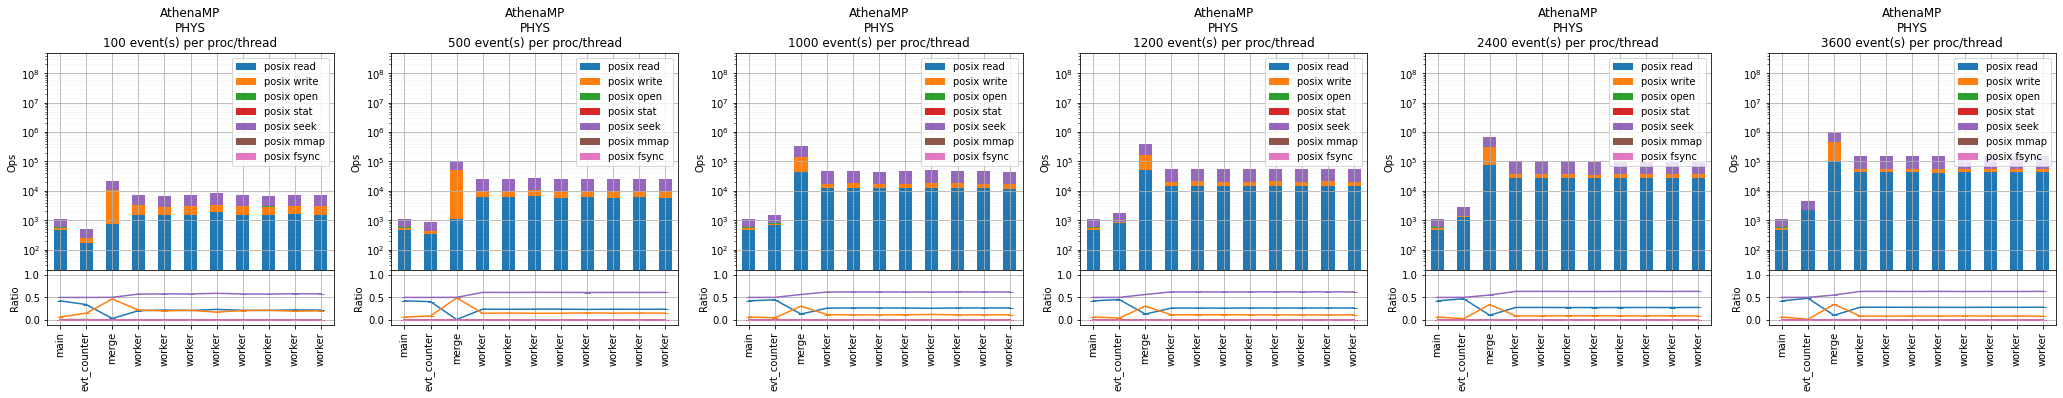

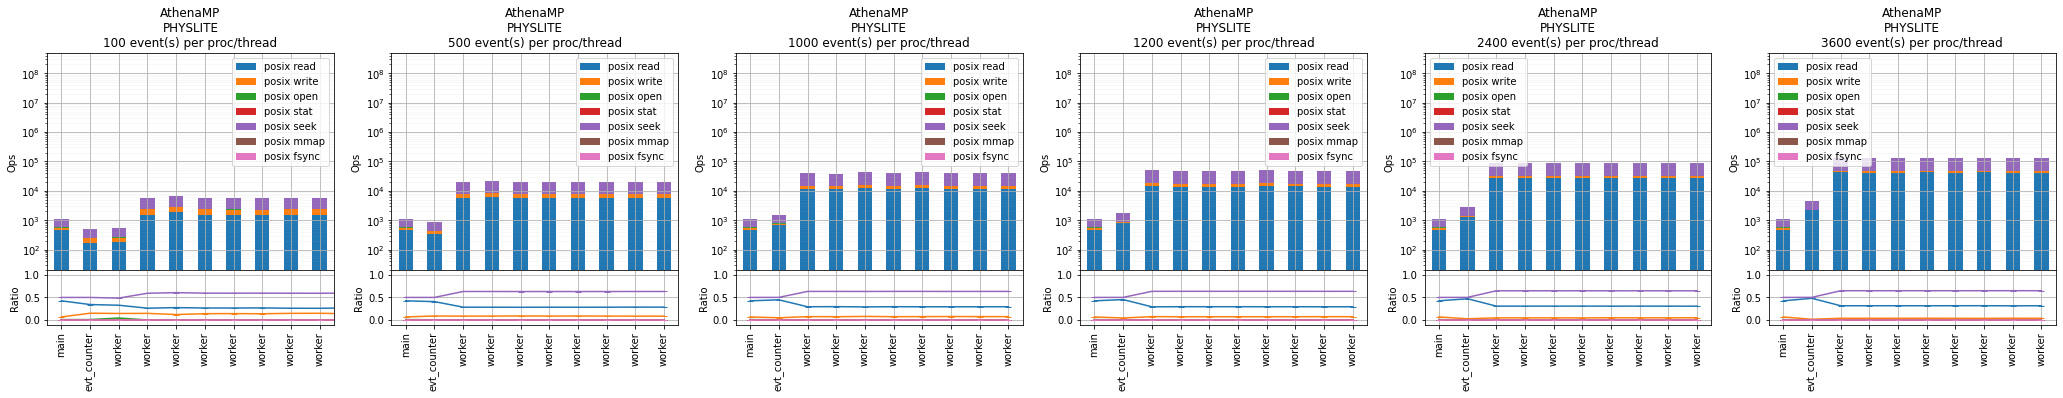

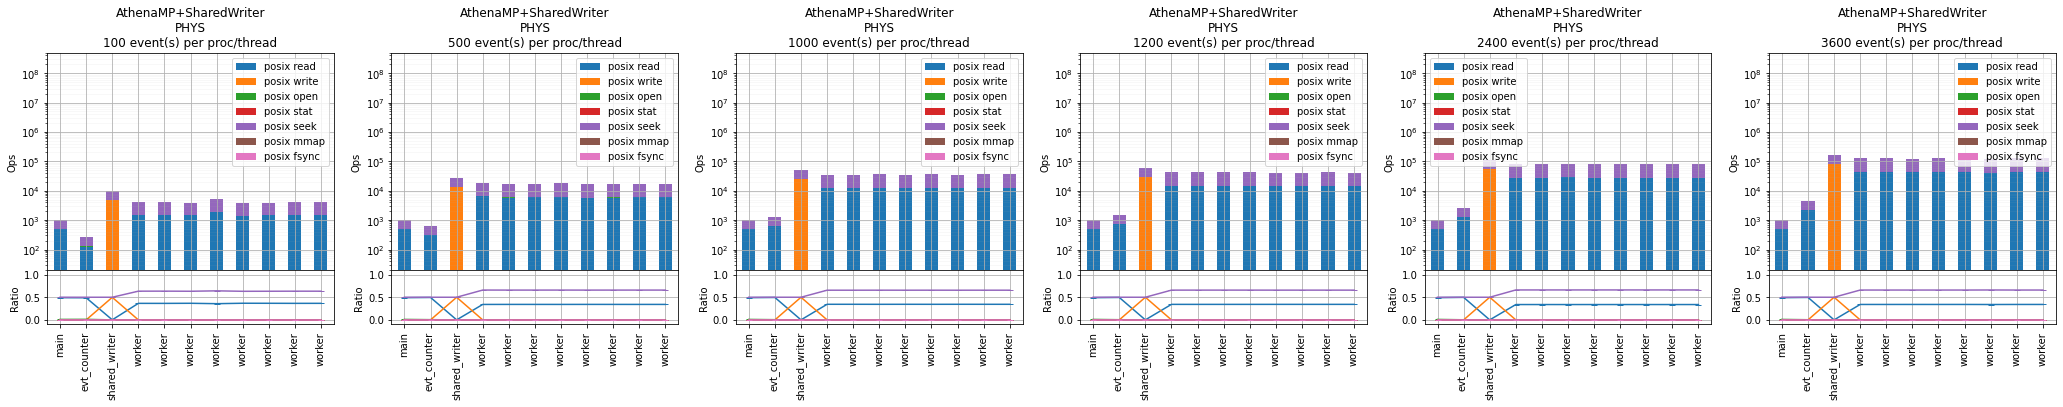

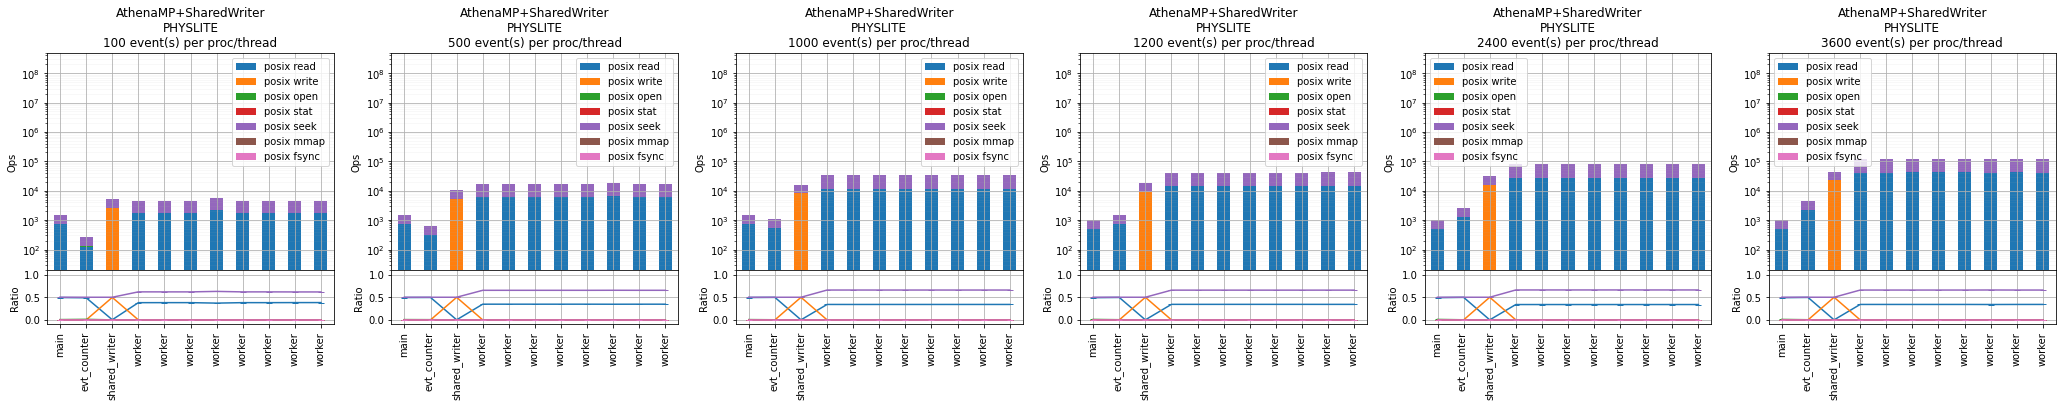

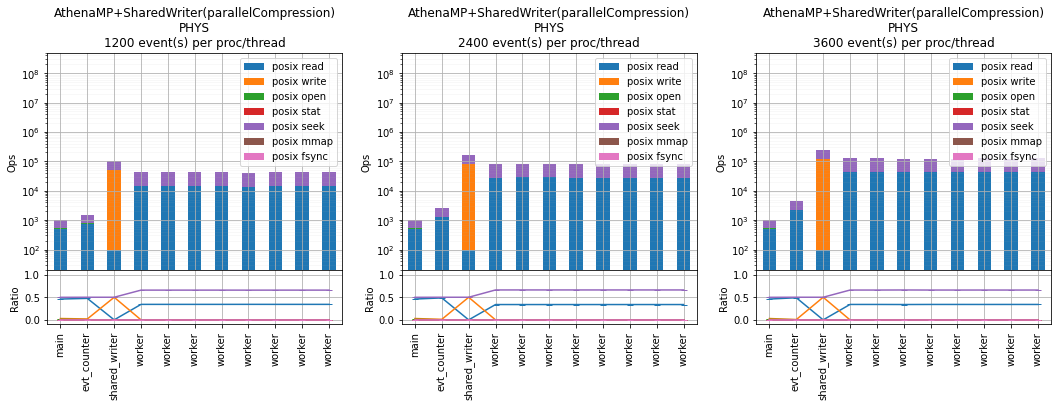

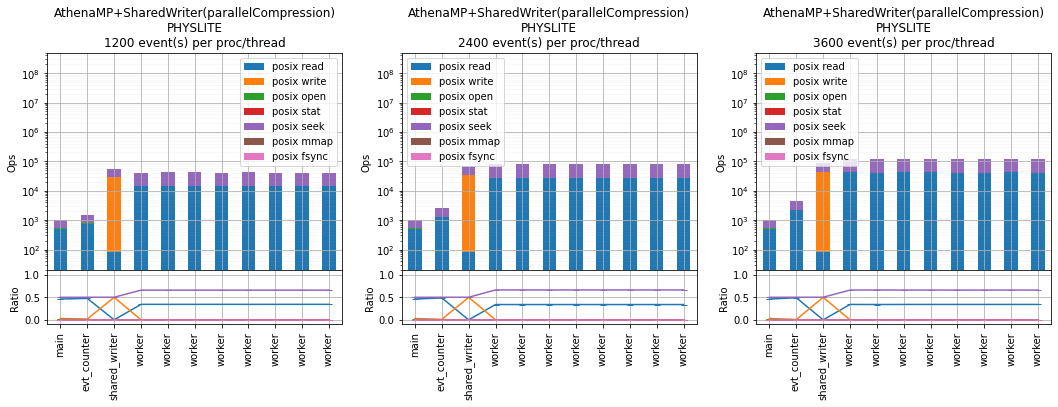

In [8]:
def plot_main_fork(df,var,xlabel,ylabel,title,logy,ylim,width=0.5):
    print(df[df.evt==100])
    df.set_index(['fork'],inplace=True)
    fig,ax = plt.subplots(2,len(df.evt.unique()),figsize=(6*len(df.evt.unique()), 5),gridspec_kw={'height_ratios':[4, 1],'wspace':0.2,'hspace':0}
                           ,sharex=True,sharey=False)
    for i,e in enumerate(np.sort(df.evt.unique())):
        tmpdf=df[df.evt==e].sort_index().reset_index()
        if len(tmpdf)>1: tmpdf=tmpdf.reindex([1,0]+list(tmpdf.index)[2:])
        rvar=[]
        for v in var:
            rvar.append(v+' ratio')
            tmpdf[v+' ratio']=tmpdf[v]/tmpdf[var].sum(axis=1)
#         print(tmpdf)
        tmpdf.loc[:,['fork']+var].plot.bar('fork',xlabel=xlabel,ylabel=ylabel,ax=ax[0][i],logy=logy,grid=True
                                                       ,title=title+str(e)+' event(s) per proc/thread'
                                                       ,legend=True,stacked=True,ylim=ylim,width=width)
        tmpdf.loc[:,['fork']+rvar].plot('fork',xlabel=xlabel,ylabel='Ratio',ax=ax[1][i],logy=False,grid=True
                                                       ,legend=False,ylim=[-0.1,1.1],rot=90,marker='_')
        ax[1][i].set_yticks([0,0.5,1])
        ax[0][i].grid(which='minor', alpha=0.1)

#     ax[2].legend()
    
#     print(df)
#     df[df.evt==1].groupby(['athena'])[var].plot.bar(xlabel=xlabel,ylabel=ylabel,title=title,ax=ax)
mods=['athenaMP (PHYS)','athenaMP (PHYSLITE)','athenaMP_shared (PHYS)','athenaMP_shared (PHYSLITE)','athenaMP_shared_parComp (PHYS)','athenaMP_shared_parComp (PHYSLITE)'] #,'athenaMP','athenaMP_shared_parComp']
titles=['AthenaMP\nPHYS\n','AthenaMP\nPHYSLITE\n','AthenaMP+SharedWriter\nPHYS\n','AthenaMP+SharedWriter\nPHYSLITE\n','AthenaMP+SharedWriter(parallelCompression)\nPHYS\n','AthenaMP+SharedWriter(parallelCompression)\nPHYSLITE\n']#,'AthenaMP\n','AthenaMP+SharedWriter(parallelCompression)\n']
# mods=['athenaMP (PHYSLITE)','athenaMP_shared (PHYSLITE)'] #,'athenaMP','athenaMP_shared_parComp']
# titles=['AthenaMP\nPHYSLITE\n','AthenaMP+SharedWriter\nPHYSLITE\n']#,'AthenaMP\n','AthenaMP+SharedWriter(parallelCompression)\n']
width=[0.5,0.5,0.5,0.5]

var=['posix read','posix write','posix open','posix stat','posix seek','posix mmap','posix fsync']
ylim=[20,5*10**8]
for i,mod in enumerate(mods):
    plot_main_fork(df[(df.athena==mod) & (df.proc==8)],var,'','Ops',titles[i],True,ylim)

# ylim=[0.02,1000]
# var=['posix bytes read','posix bytes written']#,'posix max bytes read','posix max bytes written']
# for i,mod in enumerate(mods):
#     plot_main_fork(df[(df.athena==mod) & (df.proc==8)],var,'','MB',titles[i],True,ylim,width[i])

In [2]:
# reports_ttbar[0].records['POSIX']['fcounters']#.to_numpy()
for r in freports_ttbar[:1]:
    create_timeline(r)
    print(r.filename.split('/')[3].split('_')[0:5])
    print(r.summary['timeline'])
#     for it in r.summary['timeline']['items']:
#         print(it['id'],it['name'],it['end'])

NameError: name 'freports_ttbar' is not defined

In [55]:
r.records['POSIX'].to_df()['counters'].keys()

Index(['rank', 'id', 'POSIX_OPENS', 'POSIX_FILENOS', 'POSIX_DUPS',
       'POSIX_READS', 'POSIX_WRITES', 'POSIX_SEEKS', 'POSIX_STATS',
       'POSIX_MMAPS', 'POSIX_FSYNCS', 'POSIX_FDSYNCS', 'POSIX_RENAME_SOURCES',
       'POSIX_RENAME_TARGETS', 'POSIX_RENAMED_FROM', 'POSIX_MODE',
       'POSIX_BYTES_READ', 'POSIX_BYTES_WRITTEN', 'POSIX_MAX_BYTE_READ',
       'POSIX_MAX_BYTE_WRITTEN', 'POSIX_CONSEC_READS', 'POSIX_CONSEC_WRITES',
       'POSIX_SEQ_READS', 'POSIX_SEQ_WRITES', 'POSIX_RW_SWITCHES',
       'POSIX_MEM_NOT_ALIGNED', 'POSIX_MEM_ALIGNMENT',
       'POSIX_FILE_NOT_ALIGNED', 'POSIX_FILE_ALIGNMENT',
       'POSIX_MAX_READ_TIME_SIZE', 'POSIX_MAX_WRITE_TIME_SIZE',
       'POSIX_SIZE_READ_0_100', 'POSIX_SIZE_READ_100_1K',
       'POSIX_SIZE_READ_1K_10K', 'POSIX_SIZE_READ_10K_100K',
       'POSIX_SIZE_READ_100K_1M', 'POSIX_SIZE_READ_1M_4M',
       'POSIX_SIZE_READ_4M_10M', 'POSIX_SIZE_READ_10M_100M',
       'POSIX_SIZE_READ_100M_1G', 'POSIX_SIZE_READ_1G_PLUS',
       'POSIX_SIZE_WRITE_

In [106]:
r.agg_ioops()
# !for file in $(find workdir/Athena_23_0_5/ -type f -name 'log.EVNTtoHITS'); do echo $file; done
# print(r.__dir__())
# print(r.modules)
# r.records['POSIX'].__hash__()
# nr=r.name_records
# ex_list=['.py','perfmon','PoolFileCatalog','eventLoopHeartBeat','.db','libdarshan.so','atlas-condb'
#          ,'.tmp','STD','POSIX']
# # import fname,re
# names=[]
# for k, v in nr.items():
#     match=False
#     for ex in ex_list:
#         if ex in v:
#             match=True
#             break
#     if not match:
#         names.append(v)
# print(names)
# # print(r.name_records_summary())
# rr=r.filter(name_records=names)
# print(rr.name_records_summary())
# rr.agg_ioops()
# d = {k: v for k, v in nr.items() if for }

{'POSIX': {'POSIX_OPENS': 5,
  'POSIX_FILENOS': 0,
  'POSIX_DUPS': 0,
  'POSIX_READS': 43,
  'POSIX_WRITES': 0,
  'POSIX_SEEKS': 56,
  'POSIX_STATS': 10,
  'POSIX_MMAPS': -1,
  'POSIX_FSYNCS': 0,
  'POSIX_FDSYNCS': 0,
  'POSIX_RENAME_SOURCES': 0,
  'POSIX_RENAME_TARGETS': 0,
  'POSIX_RENAMED_FROM': 0,
  'POSIX_MODE': 0,
  'POSIX_BYTES_READ': 149238,
  'POSIX_BYTES_WRITTEN': 0,
  'POSIX_MAX_BYTE_READ': 113638962,
  'POSIX_MAX_BYTE_WRITTEN': 0,
  'POSIX_CONSEC_READS': 1,
  'POSIX_CONSEC_WRITES': 0,
  'POSIX_SEQ_READS': 23,
  'POSIX_SEQ_WRITES': 0,
  'POSIX_RW_SWITCHES': 0,
  'POSIX_MEM_NOT_ALIGNED': 0,
  'POSIX_MEM_ALIGNMENT': 8,
  'POSIX_FILE_NOT_ALIGNED': 38,
  'POSIX_FILE_ALIGNMENT': 512,
  'POSIX_MAX_READ_TIME_SIZE': 43293,
  'POSIX_MAX_WRITE_TIME_SIZE': 0,
  'POSIX_SIZE_READ_0_100': 0,
  'POSIX_SIZE_READ_100_1K': 31,
  'POSIX_SIZE_READ_1K_10K': 10,
  'POSIX_SIZE_READ_10K_100K': 2,
  'POSIX_SIZE_READ_100K_1M': 0,
  'POSIX_SIZE_READ_1M_4M': 0,
  'POSIX_SIZE_READ_4M_10M': 0,
  'POSIX_S

In [ ]:
def plot_withfork(df,var,tit,ylabel):
    if 'time' in var:
        df_main=df.query("fork!=1 and proc>1 and evt!=15 ",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
        df_main[var]=df_main[var].astype("timedelta64[s]")
#         df_main[var+'_sub1']=df_main[var+'_sub1'].astype("timedelta64[s]")
    else:
        df_main=df.query("proc>1 and evt!=15 ",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
    df_main=df_main.groupby(['evt','athena','proc']).sum().reset_index(level=[0,1,2])
    for iv,v in enumerate(var):
        df_main[v+'_sub1']=df_main[v]
        for nevt in list(df_main.evt.unique()):
            if nevt==1: continue
            df_main.loc[df_main.evt==nevt,v+'_sub1']=(df_main.loc[df_main.evt==nevt,v+'_sub1']-df_main.iloc[:len(df_main.loc[df_main.evt==1])][v].values)
            df_main.loc[df_main.evt==nevt,v+'_sub1']=df_main.loc[df_main.evt==nevt,v+'_sub1']/(df_main.loc[df_main.evt==nevt,'evt']-1)/df_main.loc[df_main.evt==nevt,'proc']

    fig1,ax1 = plt.subplots(1,3,figsize=(15, 4),sharex=True,sharey=True)
    fig2,ax2 = plt.subplots(1,3,figsize=(15, 4),sharex=True,sharey=True)
    xlabel='No. of events per thread/Process'
    df_main.set_index(['evt'],inplace=True)
#     print(df_main)
    for i,p in enumerate(list(df_main.proc.unique())):
        title='total '+tit+', LCRC, '+str(p)+' thread/Process'
#         df_main.loc[df_main.proc==p].groupby(['athena'])[var].plot.bar(ax=ax1[i],label='a')
        for im,mod in enumerate(list(df_main.athena.unique())):
            width=1./len(list(df_main.athena.unique()))/8
            pos=8*width*im
            print(width,pos)
            tdf=df_main.loc[(df_main.proc==p) & (df_main.athena==mod)]
            tdf[var].plot(kind='bar',ax=ax1[i],position=pos,width=width,stacked=True)
# #         df_main.loc[df_main.proc==p].groupby(['athena'])[v].plot(xlabel=xlabel,ylabel=ylabel,marker='o',ax=ax1[i]
# #                                                                    ,title=title,logy=False,legend=True,grid=True)
#         title='per event '+tit+', LCRC, '+str(p)+' thread/Process\n(by substructing the 1 event run)'
#         pos=1./len(var)*(iv+1)
#         df_main.loc[df_main.proc==p].groupby(['athena'])[v+'_sub1'].plot(logy=True,stacked=False,kind='bar' #,marker='o'
#                                                                         ,xlabel=xlabel,ylabel=ylabel+' / event',ax=ax2[i]
# #                                                                         ,ylim=[0.1,100000]
#                                                                          ,position=pos
#                                                                            ,title=title,legend=True,grid=True)
    plt.legend()
    fig1.subplots_adjust(0,0,1,1,0,0)
    fig2.subplots_adjust(0,0,1,1,0,0)

# plt.tight_layout()
# df_main
plot_withfork(df_ttbar,['posix_read','posix_write'],'posix','Ops (Total, All Processes)')


In [ ]:
def plot(df,var,tit,ylabel):
    df_main=df.query("fork==False and proc>1 and evt!=15 ",engine='python'
                    ).sort_values(['evt','athena','proc']).reset_index(drop=True)
    df_main[var+'_sub1']=df_main[var]
    df_main.loc[df_main.evt==1,var+'_sub1']=df_main.loc[df_main.evt==1,var+'_sub1']/df_main.loc[df_main.evt==1,'evt']/df_main.loc[df_main.evt==1,'proc']
    df_main.loc[df_main.evt==5,var+'_sub1']=(df_main.loc[df_main.evt==5,var+'_sub1']-df_main.iloc[:len(df_main.loc[df_main.evt==5])][var].values)
    df_main.loc[df_main.evt==5,var+'_sub1']=df_main.loc[df_main.evt==5,var+'_sub1']/df_main.loc[df_main.evt==5,'evt']/df_main.loc[df_main.evt==5,'proc']
    df_main.loc[df_main.evt==50,var+'_sub1']=df_main.loc[df_main.evt==50,var+'_sub1']-df_main.iloc[:len(df_main.loc[df_main.evt==50])][var].values
    df_main.loc[df_main.evt==50,var+'_sub1']=df_main.loc[df_main.evt==50,var+'_sub1']/df_main.loc[df_main.evt==50,'evt']/df_main.loc[df_main.evt==50,'proc']
    if 'time' in var:
        df_main[var]=df_main[var].astype("timedelta64[s]")
        df_main[var+'_sub1']=df_main[var+'_sub1'].astype("timedelta64[s]")

    fig,ax1 = plt.subplots(1,3,figsize=(15, 4),sharex=True,sharey=True, constrained_layout=True)
    fig,ax2 = plt.subplots(1,3,figsize=(18, 4),sharex=True,sharey=True, constrained_layout=True)
    xlabel='No. of events per thread/Process'
    df_main.set_index(['evt'],inplace=True)
    for i,p in enumerate([8,16,32]):
        title='total '+tit+', LCRC, '+str(p)+' thread/Process'
        df_main.loc[df_main.proc==p].groupby(['athena'])[var].plot(xlabel=xlabel,ylabel=ylabel,marker='o',ax=ax1[i]
                                                                   ,title=title,logy=False,legend=True,grid=True)
        title='per event '+tit+', LCRC, '+str(p)+' thread/Process\n(by substructing the 1 event run)'
        df_main.loc[df_main.proc==p].groupby(['athena'])[var+'_sub1'].plot(logy=False,marker='o'
                                                                        ,xlabel=xlabel,ylabel=ylabel+' / event',ax=ax2[i]
#                                                                         ,ylim=[0.1,100000]
                                                                           ,title=title,legend=True,grid=True)
    plt.legend()

# plt.tight_layout()
# df_main
plot(df_ttbar,'time','running time','Sec')
plot(df_ttbar[df_ttbar.athena!='athenaMT'],'posix_read','posix read','Ops (Total, All Processes)')
plot(df_ttbar[df_ttbar.athena!='athenaMT'],'posix_write','posix write','Ops (Total, All Processes)')


In [ ]:
from darshan.experimental.aggregators import create_time_summary
reports_athenaMP[0].start_time

In [ ]:
reports[1].data
# reports_athena[0].summarize()

In [ ]:
print('fork_parent' in reports[1].metadata['job']['metadata'].keys())

In [ ]:
# reports_ttbar=[r for r in reports_ttbar if 'TempAthenaConfig' not in r.metadata['exe'] ]
# rs = [r for r in reports_ttbar if 'TempAthenaConfig' in r.metadata['exe'] ]
# rs[0].info()

In [ ]:
from darshan.experimental.plots import plot_dxt_heatmap2
plot_dxt_heatmap2(reports[0],mods=['DXT_POSIX'])

In [ ]:
from darshan.experimental.plots import plot_access_histogram
file='workdir/Athena_23_0_5/athenaMP_FullG4_ttbar_32_50_False/rwang_python_id170690-170690_9-3-810-9782348938453296783_1.darshan'
report=darshan.DarshanReport(file, read_all=True, dtype='numpy')
plot_access_histogram(report,'POSIX')

In [ ]:
file='workdir/Athena_23_0_5/athenaMP_FullG4_ttbar_32_50_False/rwang_python_id171872-171872_9-3-1048-14829239743032846552_1.darshan'
report=darshan.DarshanReport(file, read_all=True, dtype='numpy')
plot_access_histogram(report,'POSIX')

In [ ]:
file='workdir/Athena_23_0_5/athenaMP_FullG4_ttbar_32_50_False/rwang_python_id171872-172211_9-3-1248-6990502124633823591_1.darshan'
report=darshan.DarshanReport(file, read_all=True, dtype='numpy')
plot_access_histogram(report,'POSIX')

In [ ]:
from darshan.experimental.plots import plot_opcounts
# for r in reports:
#     plt = plot_opcounts(r,'POSIX')
#     plt.show()
plot_opcounts(reports[0],'POSIX')

In [ ]:
file="workdir/Athena_23_0_5/athena_FullG4_ttbar_8_15/rwang_python_id181758-181758_8-23-63299-13156225266158396904_1.darshan"
report = darshan.DarshanReport(file, read_all=True)  # Default behavior
report.info()

In [ ]:
report.records['DXT_POSIX'][0]._records[0].keys()

In [ ]:
plot_dxt_heatmap.plot_heatmap(report)
plt.plot()